# WISER phenotype estimation on the embedded apple example (Colab reproduction)

**Paper:** Jacquin L. *et al.* (2025), "WISER: an innovative and efficient method for correcting population structure in omics-based selection and association studies", bioRxiv 2025.02.07.637171 (preprint v1). DOI: 10.1101/2025.02.07.637171 — https://doi.org/10.1101/2025.02.07.637171

**Author code:** R package `wiser` — https://github.com/ljacquin/wiser @ `d467f97267819cf556e9f4bf62f832b80a4859c0` (pinned commit; GPL-2 | GPL-3). **AI-assisted Colab orchestration:** the authors provided an R package, not this notebook. This notebook copies the author's R code and README example unchanged and launches it with `Rscript` (Python is only the launcher, because the Colab CLI used for validation executes Python kernels). The executed example was validated, but untested behavior is not guaranteed.

**Scope (PARTIAL demonstration, executed):** WISER breeding-value estimation with `estimate_wiser_breeding_value()` and its defaults (ZCA-cor whitening, `frobenius_norm_regularization`, `alpha_ = 0.01`) on the **30-genotype apple subset embedded in the wiser package** (Jung et al. 2022 apple REFPOP-derived, illustrative only), trait `Trunk_increment`. One example run; NOT a reproduction of the paper's Tables 1–2 cross-validation benchmark, the rice/maize/pine datasets, `optimize_whitening_and_regularization()`, or published PA/h2 results.

**Runtime:** CPU only (pure R statistical computing; no GPU code path exists in the method). ランタイム → 「ランタイムのタイプを変更」→ **CPU** で実行してください。GPU は不要です。

**Expected duration / downloads:** ~5–10 minutes total; downloads < 2 MB (author R sources + two small `.rda` apple data files). 所要時間 5〜10 分、ダウンロードは 2 MB 未満。

**日本語まとめ:** 本ノートブックは、集団構造を補正する表現型推定法 WISER(Whitening + successive least squares)を、著者提供 R パッケージ `wiser`(固定コミット)に同梱されたリンゴ 30 遺伝子型の小型例データで実行します。`estimate_wiser_breeding_value()` をデフォルト設定(ZCA-cor ホワイトニング、alpha=0.01)で呼び出し、`Trunk_increment` の育種価を推定して表・図として表示します。論文の全ベンチマーク(Tables 1–2、4 作物)の再現ではありません。

**Execution status:** this notebook is delivered with saved outputs from a full top-to-bottom CPU run; see the validation record at the end.


## 1. Check the R runtime

`wiser` is an R (>= 4.2.1) package. Colab's standard runtime ships `Rscript`; this cell verifies its presence and version, and fails clearly otherwise. / R ランタイムの有無とバージョンを確認します(R >= 4.2.1 が必要)。

**Mapping to author code:** `wiser` DESCRIPTION `Depends: R (>= 4.2.1)`. The paper's computations run in R; Python here only checks the launcher.


In [ ]:
import subprocess, re

RSCRIPT = "/usr/bin/Rscript"
try:
    out = subprocess.run([RSCRIPT, "--version"], capture_output=True, text=True, timeout=60)
    mver = re.search(r"version (\d+\.\d+\.\d+)", out.stderr + out.stdout, re.I)
    rver = mver.group(1)
except Exception as e:
    raise RuntimeError(f"Rscript not available in this runtime: {e}")
print("Rscript version:", rver)
major, minor = (int(x) for x in rver.split(".")[:2])
assert (major, minor) >= (4, 2), f"R {rver} is too old; wiser requires R >= 4.2.1"
print("R version OK")

Rscript version: 4.6.1
R version OK


## 2. Install the minimal R dependencies

The minimal example path uses only: **MASS, Matrix** (recommended, preinstalled), **matrixcalc, whitening, stringr, tidyr, future, future.apply** (all CRAN). The heavier `wiser` Imports used by other functions (`mixOmics`, `ranger`, `KRMM`, `glmnet`, `kernlab`, `Rfast`) are **not** on this path and are not installed. / 最小経路で必要な CRAN パッケージのみインストールします(数分)。


In [ ]:
import subprocess

RSCRIPT = "/usr/bin/Rscript"
R_PKGS = ["matrixcalc", "whitening", "stringr", "tidyr", "future", "future.apply"]
pkgs_r = ", ".join('"%s"' % p for p in R_PKGS)
install_script = (
    "ip <- installed.packages()[, 'Package']\n"
    "to_install <- c(" + pkgs_r + ")\n"
    "to_install <- to_install[!to_install %in% ip]\n"
    "if (length(to_install) > 0) install.packages(to_install, repos = 'https://cloud.r-project.org')\n"
    "cat('install step done\n')\n"
)
with open("/content/install_r_deps.R", "w") as f:
    f.write(install_script)
proc = subprocess.run([RSCRIPT, "/content/install_r_deps.R"], timeout=1800)
assert proc.returncode == 0, f"R package installation failed: rc={proc.returncode}"
for p in R_PKGS:
    v = subprocess.run([RSCRIPT, "-e", 'cat(as.character(packageVersion("%s")))' % p],
                       capture_output=True, text=True, timeout=120).stdout
    print(p, v)

matrixcalc 1.0.6


whitening 1.4.0


stringr 1.6.0


tidyr 1.3.2


future 1.76.0


future.apply 1.20.2


## 3. Acquire the pinned author code and the apple example data

A **partial clone of the author repository is performed inside Colab only** (this is the documented Colab route; no data is downloaded to any authoring host). The clone is pinned to commit `d467f97267819cf556e9f4bf62f832b80a4859c0` in detached HEAD and asserted; only `R/` (all author R sources, so every helper is present and identical to the pinned revision) and the two small apple `.rda` data files are checked out. / 著者リポジトリの部分クローンを Colab 内で行い、固定コミットであることを検証してから `R/` とリンゴの 2 つの `.rda` データのみチェックアウトします。


In [ ]:
import subprocess, os

REPO_URL = "https://github.com/ljacquin/wiser.git"
COMMIT = "d467f97267819cf556e9f4bf62f832b80a4859c0"
os.makedirs("/content/wiser", exist_ok=True)

def sh(cmd, timeout=600):
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=timeout)
    if p.returncode != 0:
        raise RuntimeError(f"{cmd} failed:\n{p.stdout[-1500:]}\n{p.stderr[-1500:]}")
    return p.stdout

sh("git -C /content/wiser init -q && git -C /content/wiser config extensions.partialClone origin && git -C /content/wiser remote add origin " + REPO_URL)
sh("git -C /content/wiser sparse-checkout init --no-cone && git -C /content/wiser sparse-checkout set 'R/**' 'data/apple_*.rda'")
sh(f"git -C /content/wiser fetch --depth 1 --filter=blob:none origin {COMMIT}")
sh(f"git -C /content/wiser checkout -q --detach {COMMIT}")
head = sh("git -C /content/wiser rev-parse HEAD").strip()
assert head == COMMIT, f"checkout mismatch: {head} != {COMMIT}"

EXPECTED_SIZES = {"data/apple_raw_pheno_data.rda": 46318, "data/apple_genomic_data.rda": 421268}
for f, exp in EXPECTED_SIZES.items():
    path = os.path.join("/content/wiser", f)
    size = os.path.getsize(path)
    with open(path, "rb") as fh:
        magic = fh.read(2)
    assert size == exp, f"{f}: size {size} != expected {exp}"
    assert magic[:2] in (b"X\n", b"BZ", b"\x1f\x8b", b"zP"), f"{f}: not a recognized R data payload (magic={magic!r})"
    print(f"{f}: {size} bytes OK")
print("pinned commit verified:", head)

data/apple_raw_pheno_data.rda: 46318 bytes OK
data/apple_genomic_data.rda: 421268 bytes OK
pinned commit verified: d467f97267819cf556e9f4bf62f832b80a4859c0


**Validation of downloaded bytes:** the two `.rda` files are R serialized data (`X\n` magic), their sizes match the pinned GitHub tree metadata exactly, and the checked-out commit was asserted equal to the pin. Actual data schema is verified in the next cell by loading and previewing. / ダウンロードした `.rda` のサイズ・形式を検証し、次のセルで実際のデータを読み込んで確認します。

## 4. Load and preview the apple example data (Colab-side schema inspection)

This is the first time the data bytes are inspected (dataset bytes are kept off the authoring host). We reproduce the README example's data preparation verbatim: build `Envir = Country_Year_Management` and set genotypes as row names. / データの内容を検証し、README 例どおりに `Envir` を作成します。


In [ ]:
RSCRIPT = "/usr/bin/Rscript"
rscript = r'''
options(width = 100)
load("/content/wiser/data/apple_raw_pheno_data.rda")
load("/content/wiser/data/apple_genomic_data.rda")

# README example (lines 140-158): environments and genotype row names
apple_raw_pheno_data$Envir <- paste0(apple_raw_pheno_data$Country, "_",
                                     apple_raw_pheno_data$Year, "_",
                                     apple_raw_pheno_data$Management)
rownames(apple_genomic_data) <- apple_genomic_data$Genotype
apple_genomic_data <- apple_genomic_data[, -match("Genotype", colnames(apple_genomic_data))]

cat("raw pheno dim:", dim(apple_raw_pheno_data), "\n")
cat("columns:", paste(colnames(apple_raw_pheno_data), collapse = ", "), "\n")
cat("genomic dim (genotypes x markers):", dim(apple_genomic_data), "\n")
cat("environments:", length(unique(apple_raw_pheno_data$Envir)), "\n")
cat("Trunk_increment non-NA rows:", sum(!is.na(apple_raw_pheno_data$Trunk_increment)), "\n")
cat("Trunk_increment summary (units as published):\n")
print(summary(apple_raw_pheno_data$Trunk_increment))
cat("first 3 rows of relevant columns:\n")
print(head(apple_raw_pheno_data[, intersect(c("Genotype","Envir","Row","Position","Trunk_increment"), colnames(apple_raw_pheno_data))], 3))
'''
with open("/content/preview_data.R", "w") as f:
    f.write(rscript)
p = subprocess.run([RSCRIPT, "/content/preview_data.R"], capture_output=True, text=True, timeout=600)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr[-3000:])
    raise RuntimeError(f"data preview failed: rc={p.returncode}")

raw pheno dim: 2117 25 
columns: Row, Position, Genotype, Management, Checks, Year, Country, Harvest_date, Fruit_weight, Fruit_number, Fruit_weight_single, Color_over, Russet_freq_all, Trunk_diameter, Trunk_increment, Flowering_intensity, Flowering_begin, Flowering_full, Flowering_end, Scab, Powdery_mildew, Scab_fruits, Sample_size, Weight_sample, Envir 
genomic dim (genotypes x markers): 30 50000 
environments: 46 
Trunk_increment non-NA rows: 1742 
Trunk_increment summary (units as published):
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  0.000   2.272   4.200   5.278   7.000  41.000     375 
first 3 rows of relevant columns:
    Genotype      Envir Row Position Trunk_increment
10      2061 BEL_2018_1  12       10            3.81
26       526 BEL_2018_1  12       26            1.13
106      575 BEL_2018_1  13       13            2.55



## 5. Run WISER breeding-value estimation (author README example, lines 160–188)

**Source-to-Colab mapping:** all `R/*.R` sources of `wiser` @ `d467f97267819cf556e9f4bf62f832b80a4859c0` are sourced unchanged; `estimate_wiser_breeding_value()` is called exactly as in the author README with `trait_ = "Trunk_increment"`, `fixed_effect_vars = c("Envir","Row","Position")`, `random_effect_vars = "Genotype"`, and the function's own defaults (`whitening_method = "ZCA-cor"`, `regularization_method = "frobenius_norm_regularization"`, `alpha_ = 0.01`, `n_sim_abc = 100`, `seed_abc = 123`). The overall mean is always fitted inside the wiser framework (author note). No parameter was altered. / 著者 README の呼び出しをそのまま実行します(パラメータ変更なし)。


In [ ]:
RSCRIPT = "/usr/bin/Rscript"
rscript = r'''
suppressMessages({
  library(MASS); library(Matrix); library(matrixcalc); library(whitening)
  library(stringr); library(tidyr); library(future.apply)
})
for (rfile in sort(list.files("/content/wiser/R", full.names = TRUE, pattern = "\\.R$"))) {
  source(rfile)
}
cat("sourced R files:", length(list.files("/content/wiser/R", pattern = "\\.R$")), "\n")

load("/content/wiser/data/apple_raw_pheno_data.rda")
load("/content/wiser/data/apple_genomic_data.rda")
apple_raw_pheno_data$Envir <- paste0(apple_raw_pheno_data$Country, "_",
                                     apple_raw_pheno_data$Year, "_",
                                     apple_raw_pheno_data$Management)
rownames(apple_genomic_data) <- apple_genomic_data$Genotype
apple_genomic_data <- apple_genomic_data[, -match("Genotype", colnames(apple_genomic_data))]
trait_ <- "Trunk_increment"

t0 <- Sys.time()
wiser_obj <- estimate_wiser_breeding_value(
  omic_df = apple_genomic_data,
  raw_pheno_df = apple_raw_pheno_data,
  trait_ = trait_,
  fixed_effect_vars = c("Envir", "Row", "Position"),
  fixed_effect_vars_computed_as_factor = c("Envir", "Row", "Position"),
  envir_var = "Envir",
  fixed_effect_vars_computed_as_factor_by_envir = c("Row", "Position"),
  random_effect_vars = "Genotype"
)
elapsed <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

if (is.null(wiser_obj)) stop("estimate_wiser_breeding_value returned NULL (error printed above)")

cat("elapsed seconds:", round(elapsed, 1), "\n")
cat("WISER breeding values for", nrow(wiser_obj$wiser_breeding_values), "genotypes\n")
cat("ABC variance component estimate sigma2_u_hat_mean:", wiser_obj$wiser_abc_variance_component_estimates$sigma2_u_hat_mean, "\n")
cat("ABC variance component estimate sigma2_e_hat_mean:", wiser_obj$wiser_abc_variance_component_estimates$sigma2_e_hat_mean, "\n")
cat("whitening method: ZCA-cor; w_mat dim:", paste(dim(wiser_obj$w_mat), collapse = "x"), "\n")
cat("fixed-effect estimates (first 10):\n")
print(head(wiser_obj$wiser_fixed_effect_estimates, 10))

bv <- wiser_obj$wiser_breeding_values
write.csv(bv, "/content/wiser_breeding_values_apple_trunk_increment.csv", row.names = FALSE)
cat("saved /content/wiser_breeding_values_apple_trunk_increment.csv\n")
'''
with open("/content/run_wiser_example.R", "w") as f:
    f.write(rscript)
p = subprocess.run([RSCRIPT, "/content/run_wiser_example.R"], capture_output=True, text=True, timeout=3600)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr[-5000:])
    raise RuntimeError(f"wiser example failed: rc={p.returncode}")

sourced R files: 31 
elapsed seconds: 35.4 
WISER breeding values for 30 genotypes
ABC variance component estimate sigma2_u_hat_mean: 10.49515 
ABC variance component estimate sigma2_e_hat_mean: 10.98259 
whitening method: ZCA-cor; w_mat dim: 1742x1742 
fixed-effect estimates (first 10):
        fixed_effect_var beta_hat_var
1            (Intercept)    3739.4573
2       Envir_BEL_2019_1   -2001.8608
3       Envir_BEL_2020_1   -1753.3786
4       Envir_BEL_2021_1   -1970.1583
5       Envir_BEL_2022_1   -1059.2503
6       Envir_CHE_2019_1    -571.9457
7  Envir_CHE_2019_BUFFER   -1183.8240
8       Envir_CHE_2020_1    1268.1012
9       Envir_CHE_2020_2     406.4483
10      Envir_CHE_2021_1     746.6347
saved /content/wiser_breeding_values_apple_trunk_increment.csv



## 6. Results table and plot

The saved breeding values are displayed as a summary table and a distribution plot. The plot is **created for this notebook** (the paper reports cross-validated PA comparisons, not a per-genotype plot of this subset); it visualizes the actual computed values with genotype identifiers. / 結果を表と図で表示します(図は本ノートブックで追加作成した可視化であり、論文の図の再現ではありません)。


rows: 30; columns: ['Genotype', 'v_hat']
count    30.000
mean     -0.006
std       0.880
min      -1.988
25%      -0.518
50%      -0.069
75%       0.549
max       1.540


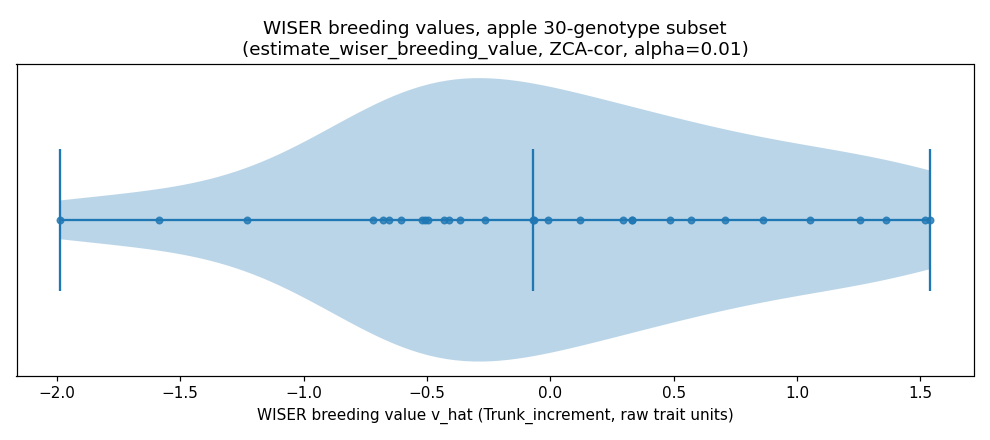

In [ ]:
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

bv = pd.read_csv("/content/wiser_breeding_values_apple_trunk_increment.csv")
print(f"rows: {len(bv)}; columns: {list(bv.columns)}")
print(bv["v_hat"].describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.violinplot(bv["v_hat"], vert=False, showmedians=True)
ax.scatter(bv["v_hat"], [1] * len(bv), s=18, alpha=0.8, color="tab:blue")
ax.set_yticks([])
ax.set_xlabel("WISER breeding value v_hat (Trunk_increment, raw trait units)")
ax.set_title("WISER breeding values, apple 30-genotype subset\n(estimate_wiser_breeding_value, ZCA-cor, alpha=0.01)")
fig.tight_layout()
fig.savefig("wiser_breeding_values_apple.png", dpi=110)
plt.close(fig)
from IPython.display import Image, display
display(Image(filename="wiser_breeding_values_apple.png"))

bv.sort_values("v_hat", ascending=False).to_csv("/content/wiser_breeding_values_sorted.csv", index=False)

## 7. Interpretation, limitations, validation record

**What was executed:** the author's documented example on the embedded 30-genotype apple subset: WISER breeding values for `Trunk_increment` via `estimate_wiser_breeding_value()` with defaults, on a fresh Colab CPU runtime (R version and package versions are shown in the outputs above; elapsed time is printed in the run cell).

**Interpretation:** `v_hat` is the genotype breeding value with fixed effects (environment, row/position within environment, intercept) removed under the ZCA-cor-whitened OLS framework (paper §2.1; `estimate_wiser_breeding_value.R` lines 106–118). The ABC variance-component estimates are also printed. Values are in the raw trait's units and are comparable across genotypes of this subset only.

**Differences from the paper / limitations:**
- One trait, one small 30-genotype illustrative subset — this does not verify the paper's Tables 1–2 results, PA gains (median +0.22 over LS-means), heritability improvements, or the rice/maize/pine analyses.
- `optimize_whitening_and_regularization()` was not run (author note: defaults are typically satisfactory for small examples; optimization is recommended when feasible).
- The supplementary PDF (ABC and regularization details) was not read; the executed ABC call follows the author code defaults exactly.
- The Colab CLI used for validation executes Python kernels, so R runs via `Rscript` subprocesses; all scientific computation (data loading, whitening, OLS, ABC) is unchanged author R code executed in R.

**日本語:** 実行したのは、同梱のリンゴ 30 遺伝子型サブセットへの 1 形質(`Trunk_increment`)の例実行です。論文の Table 1–2 の結果や PA 改善幅の検証ではありません。`optimize_whitening_and_regularization()` は実行していません(著者の注記どおりデフォルト設定を使用)。すべての科学計算は著者の R コード(Rscript)がそのまま実行しています。

**References:**
- Paper: https://doi.org/10.1101/2025.02.07.637171 (bioRxiv preprint v1)
- Code: https://github.com/ljacquin/wiser @ `d467f97267819cf556e9f4bf62f832b80a4859c0` (GPL-2 | GPL-3)
- Data: `data/apple_raw_pheno_data.rda`, `data/apple_genomic_data.rda` (embedded illustrative subsets; apple REFPOP data of Jung et al. 2022, per author README)
